In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 300)




In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head(10)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,No
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,No
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,No
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,Yes
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,No


In [ ]:
for col in df.columns:
    print(f"Unique values in column '{col}': {df[col].unique()}")


Unique values in column 'id': [     0      1      2 ... 594191 594192 594193]
Unique values in column 'gender': ['Male' 'Female']
Unique values in column 'SeniorCitizen': [0 1]
Unique values in column 'Partner': ['Yes' 'No']
Unique values in column 'Dependents': ['Yes' 'No']
Unique values in column 'tenure': [29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]
Unique values in column 'PhoneService': ['Yes' 'No']
Unique values in column 'MultipleLines': ['No' 'Yes' 'No phone service']
Unique values in column 'InternetService': ['DSL' 'Fiber optic' 'No']
Unique values in column 'OnlineSecurity': ['Yes' 'No' 'No internet service']
Unique values in column 'OnlineBackup': ['No' 'Yes' 'No internet service']
Unique values in column 'DeviceProtection': ['Yes' 'No' 'No internet service']
Unique values in column 'TechSupport': ['Ye

In [ ]:
df.columns.tolist()


['id',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

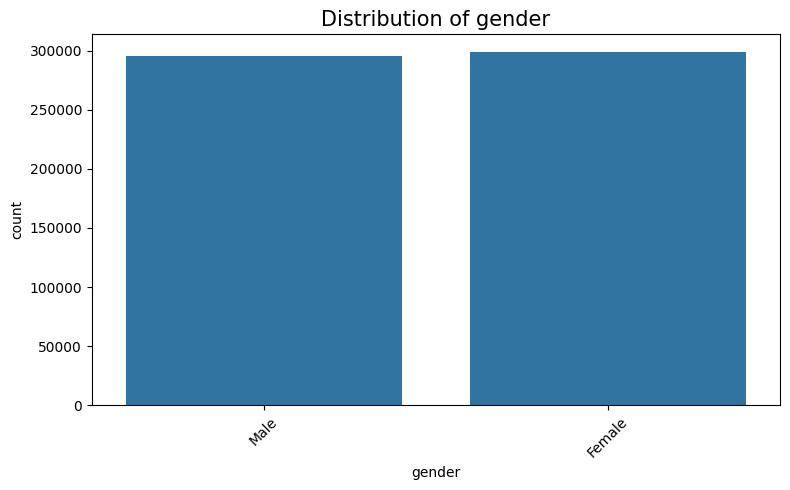

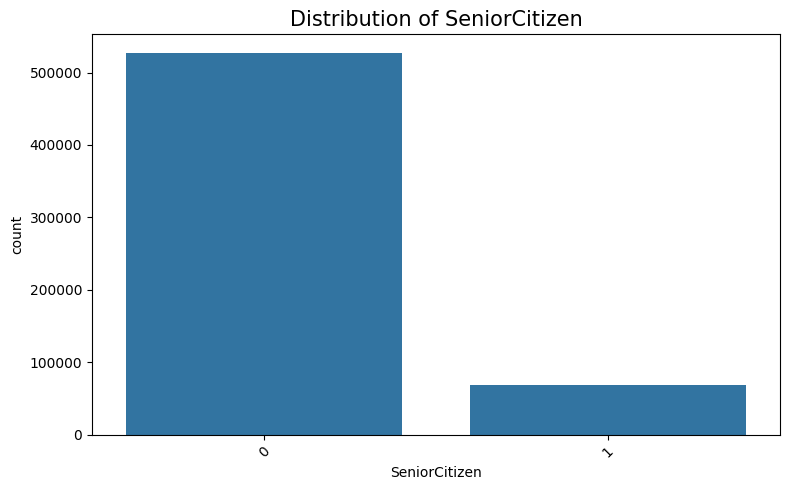

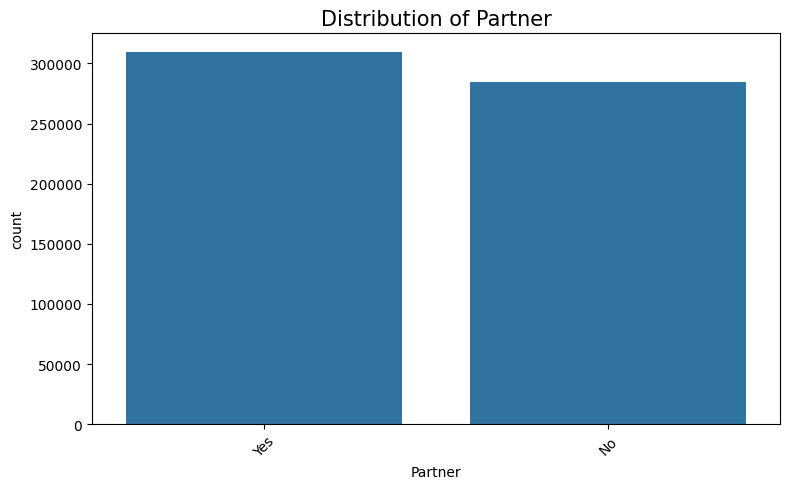

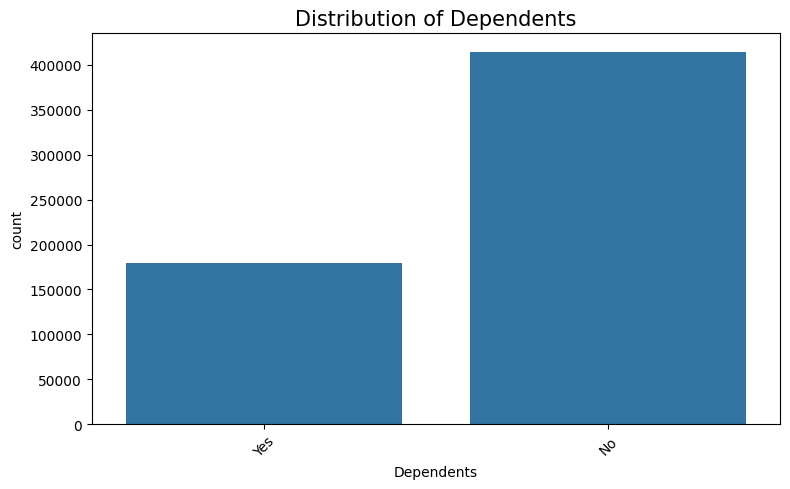

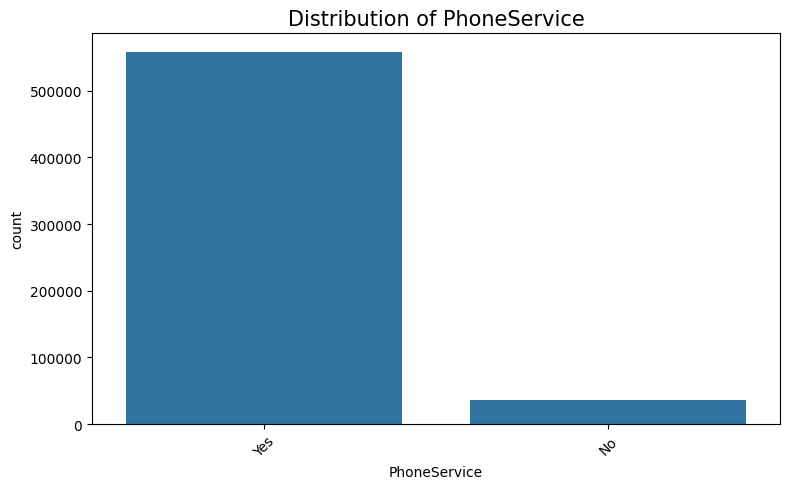

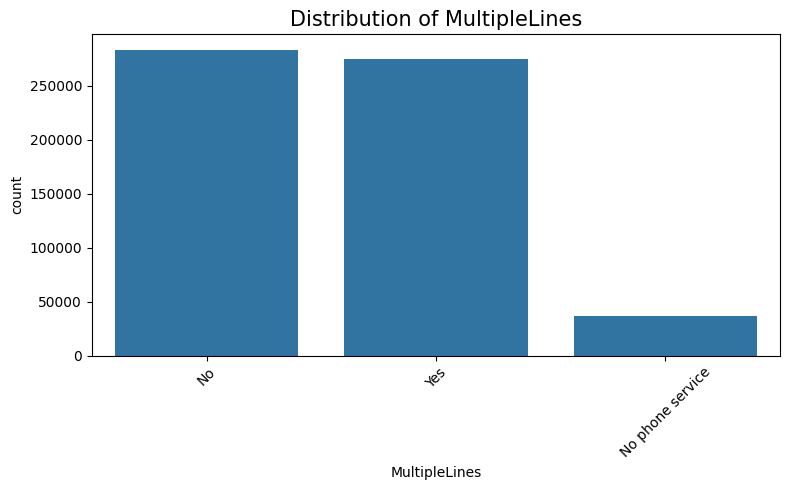

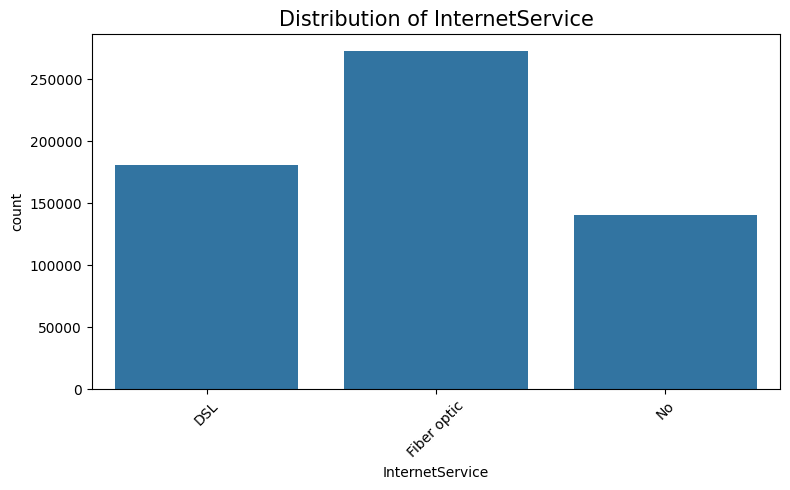

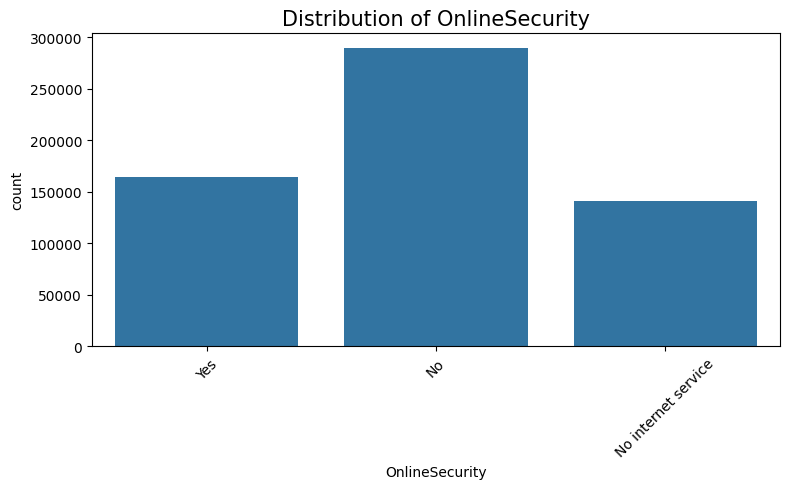

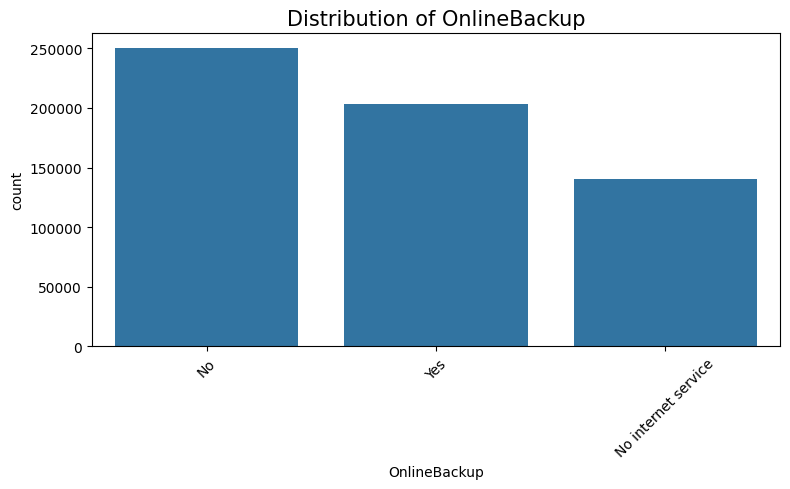

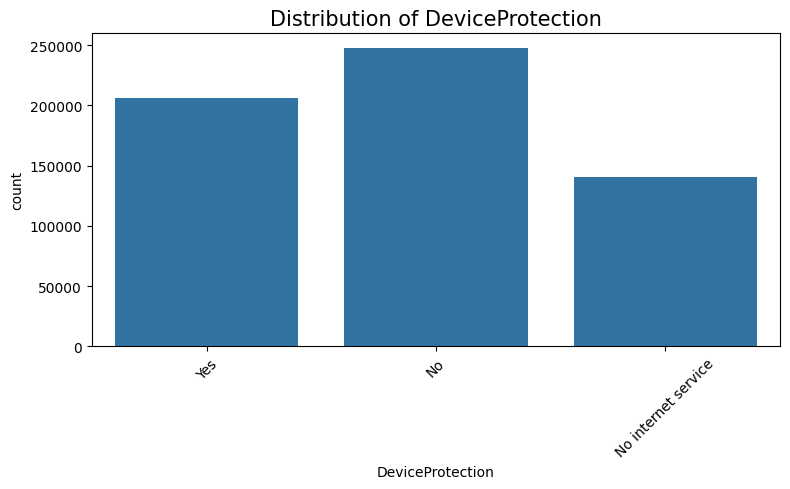

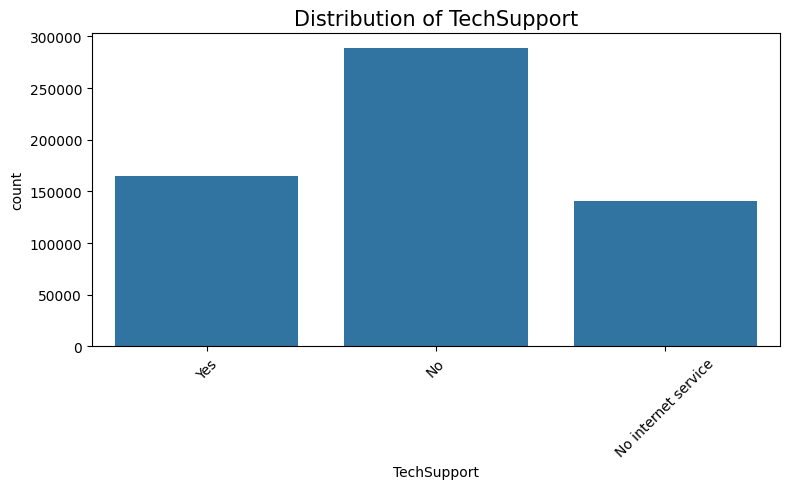

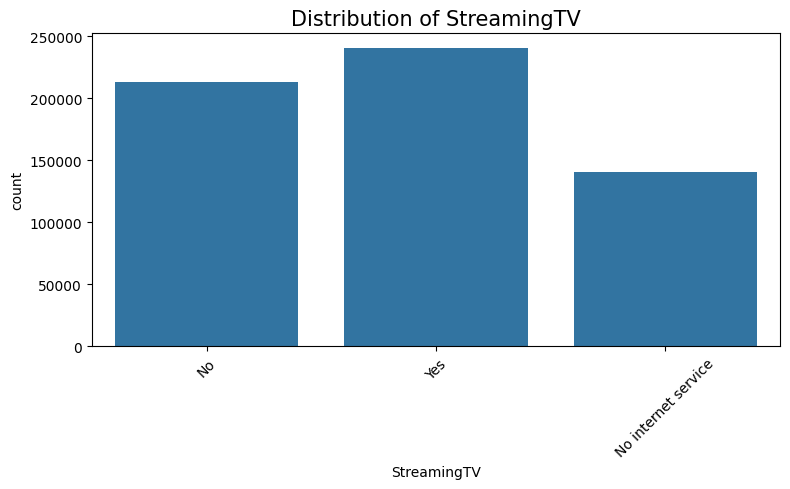

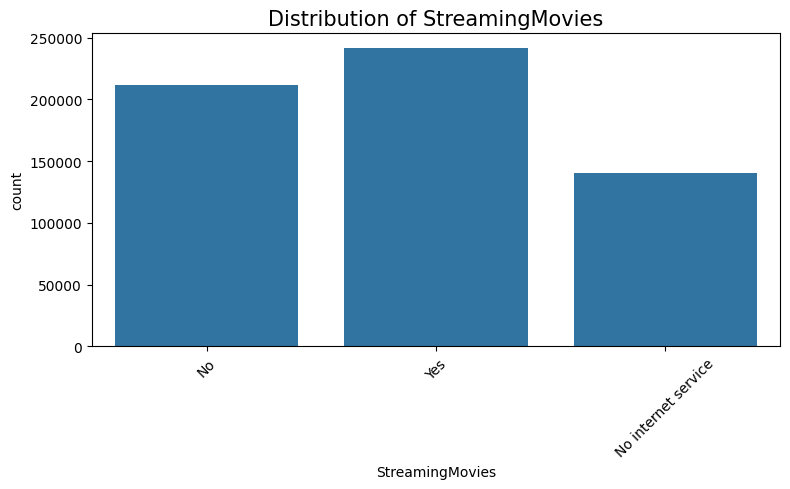

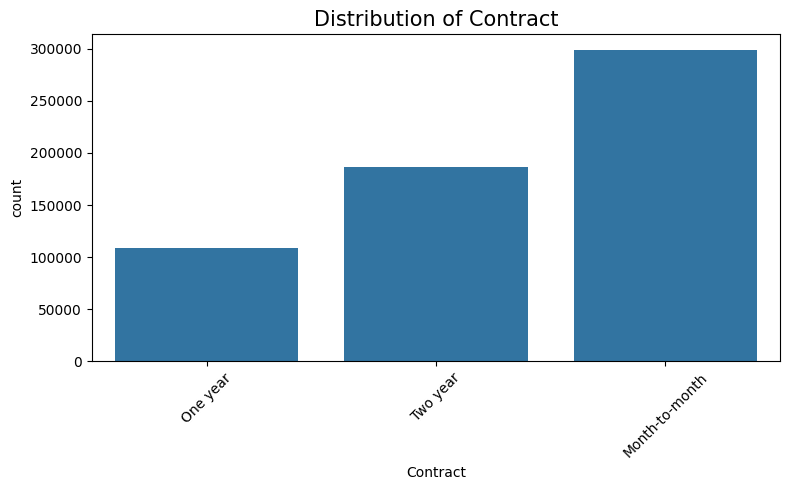

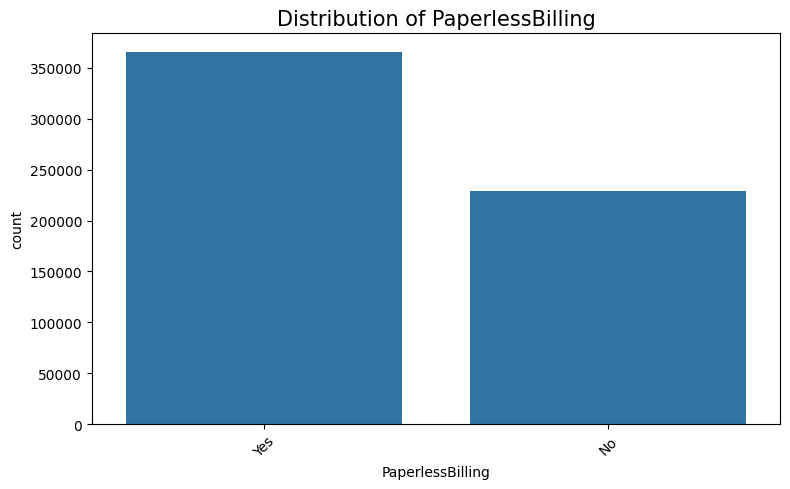

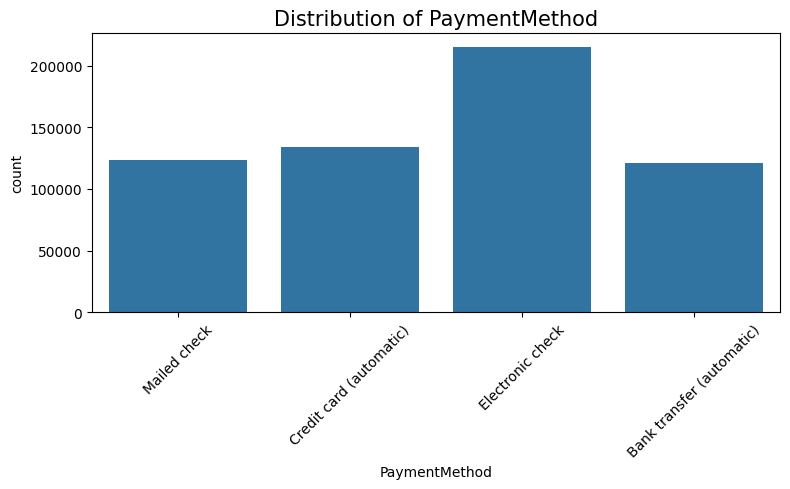

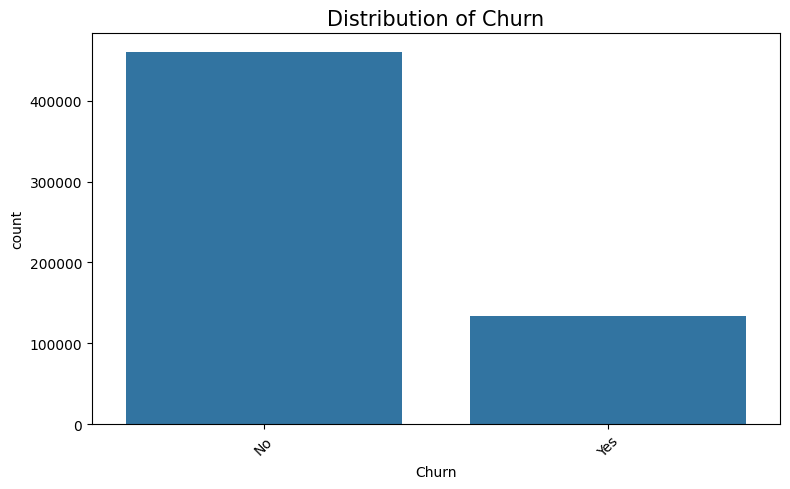

In [ ]:
cat_cols = [
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

for col in cat_cols:
    plt.figure(figsize=(8, 5))  # Create a new figure for each plot
    sns.countplot(data=df, x=col)

    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xticks(rotation=45)    # Rotate labels if they overlap
    plt.tight_layout()         # Adjusts layout for perfect fit
    plt.show()

In [ ]:
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000


In [ ]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.579457,0.420543
One year,0.942372,0.057628
Two year,0.990018,0.009982


<Axes: xlabel='Contract', ylabel='count'>

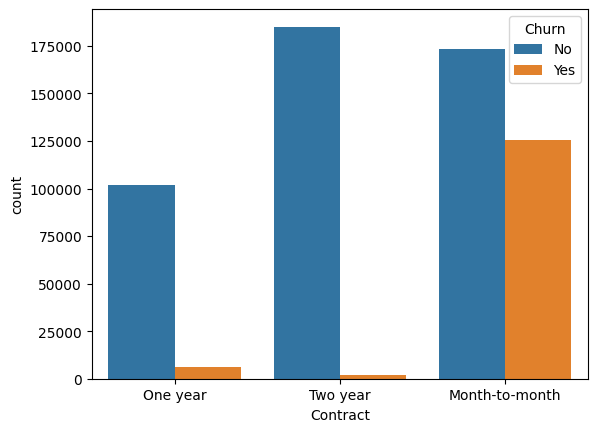

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)

<Axes: xlabel='PaymentMethod', ylabel='count'>

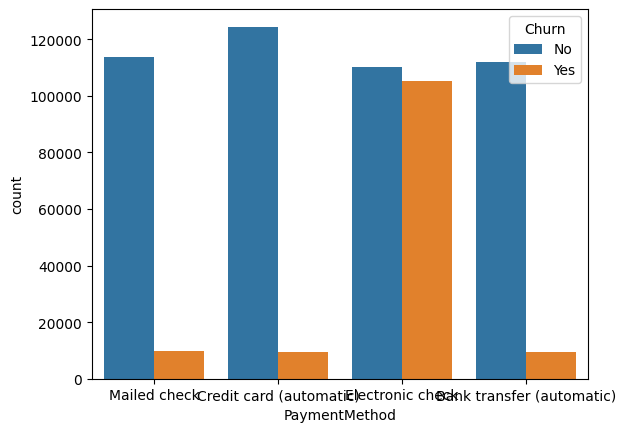

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

<Axes: xlabel='InternetService', ylabel='count'>

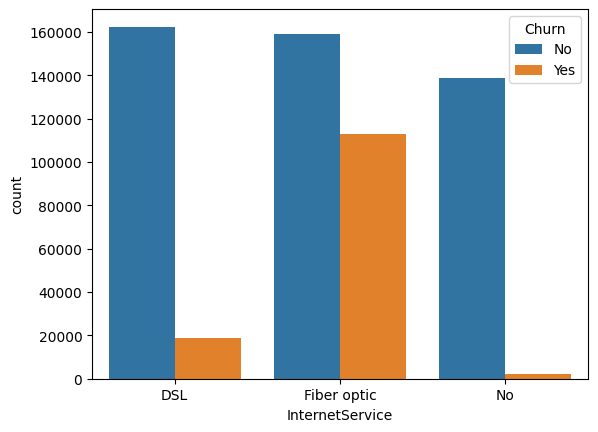

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

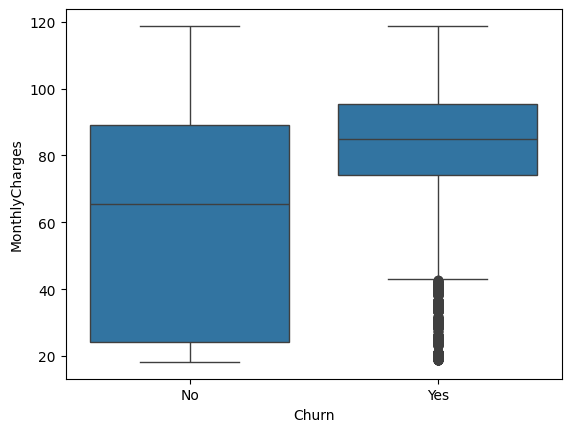

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)


<Axes: xlabel='Churn', ylabel='tenure'>

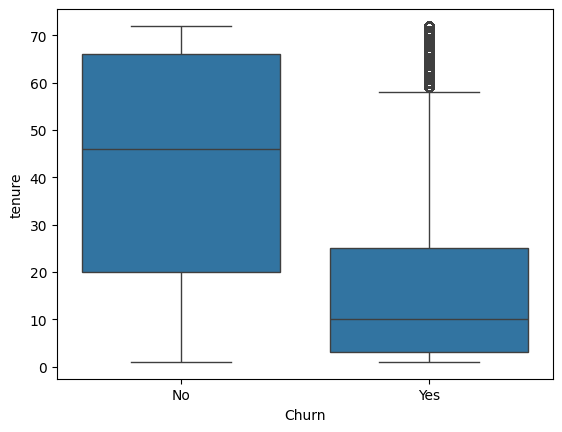

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)

In [ ]:
df = df.drop(columns=['id'])

<Axes: >

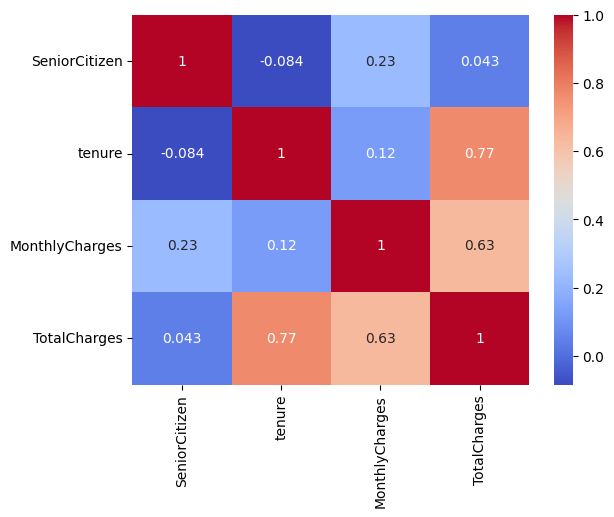

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [4]:
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0, 12, 24, 48, 60, 100],
                           labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5+yr'])

In [5]:
df['is_new_customer'] = df['tenure'].apply(lambda x: 'Yes' if x <= 12 else 'No')



In [8]:
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [10]:
df['high_value_customer'] = df['MonthlyCharges'].apply(lambda x: 'Yes' if x > 70 else 'No')

In [12]:
services = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies']

df['total_services'] = df[services].apply(lambda x: sum([1 for i in x if 'Yes' in str(i)]), axis=1)

In [14]:
internet_services = ['OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies']

df['internet_service_count'] = df[internet_services].apply(
    lambda x: sum([1 for i in x if i == 'Yes']), axis=1)

In [16]:
df['is_fiber_user'] = df['InternetService'].apply(lambda x: 'Yes' if x == 'Fiber optic' else 'No')

In [18]:
df['no_internet'] = df['InternetService'].apply(lambda x: 'Yes' if x == 'No' else 'No')

In [20]:
df['has_multiple_lines'] = df['MultipleLines'].apply(
    lambda x: 'Yes' if x == 'Yes' else 'No')

In [22]:
df['auto_payment'] = df['PaymentMethod'].apply(
    lambda x: 'Yes' if 'automatic' in x else 'No')

In [24]:
df['risky_payment'] = df['PaymentMethod'].apply(
    lambda x: 'Yes' if x == 'Electronic check' else 'No')

In [26]:
df['long_term_contract'] = df['Contract'].apply(
    lambda x: 'Yes' if x in ['One year', 'Two year'] else 'No')

In [28]:
df['month_to_month'] = df['Contract'].apply(
    lambda x: 'Yes' if x == 'Month-to-month' else 'No')

In [30]:
df['has_family'] = df.apply(
    lambda x: 'Yes' if x['Partner'] == 'Yes' or x['Dependents'] == 'Yes' else 'No',
    axis=1)

In [32]:
df['senior_citizen_flag'] = df['SeniorCitizen'].apply(
    lambda x: 'Yes' if x == 1 else 'No')

In [34]:
df['streaming_bundle'] = df.apply(
    lambda x: 'Yes' if x['StreamingTV'] == 'Yes' and x['StreamingMovies'] == 'Yes' else 'No',
    axis=1)

In [36]:


# 1. Define the scoring logic
def get_risk_score(df):
    # Initialize the score
    score = pd.Series(0, index=df.index)

    # Contract Risk (The strongest predictor)
    score += df['Contract'].map({'Month-to-month': 3, 'One year': 1, 'Two year': 0})

    # Payment Method Risk
    score += (df['PaymentMethod'] == 'Electronic check').astype(int) * 2

    # Tenure Risk (Newer customers are more volatile)
    score += np.where(df['tenure'] < 12, 2, 0)
    score += np.where((df['tenure'] >= 12) & (df['tenure'] < 24), 1, 0)

    # Lack of "Sticky" Services (Security & Tech Support)
    # We only penalize 'No' - 'No internet service' is considered neutral/low risk
    score += (df['OnlineSecurity'] == 'No').astype(int)
    score += (df['TechSupport'] == 'No').astype(int)

    # Internet Type Risk (Fiber optic has higher churn rates in this data)
    score += (df['InternetService'] == 'Fiber optic').astype(int)

    # Demographic Risk
    score += df['SeniorCitizen'] # Already 0 or 1
    score += (df['Partner'] == 'No').astype(int)

    return score

# 2. Create the column
df['risk_score'] = get_risk_score(df)

# Optional: Normalize to a 0-10 scale for easier interpretation
df['risk_score_norm'] = (df['risk_score'] / df['risk_score'].max()) * 10

In [ ]:
df.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,is_new_customer,avg_monthly_spend,high_value_customer,total_services,internet_service_count,is_fiber_user,no_internet,has_multiple_lines,auto_payment,risky_payment,long_term_contract,month_to_month,has_family,senior_citizen_flag,streaming_bundle,risk_score,risk_score_norm
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No,2-4yr,No,55.128333,No,4,3,No,No,No,No,No,Yes,No,Yes,No,No,1,0.833333
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No,4-5yr,No,64.037288,No,5,4,No,No,No,Yes,No,Yes,No,Yes,No,No,0,0.000000
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No,4-5yr,No,99.005932,Yes,5,3,Yes,No,Yes,No,Yes,No,Yes,Yes,No,Yes,8,6.666667
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes,0-1yr,Yes,35.350000,No,1,0,Yes,No,No,No,Yes,No,Yes,No,No,No,11,9.166667
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes,0-1yr,Yes,35.225000,Yes,1,0,Yes,No,No,No,Yes,No,Yes,No,No,No,11,9.166667
5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,No,0-1yr,Yes,10.100000,No,1,0,No,Yes,No,Yes,No,No,Yes,Yes,No,No,5,4.166667
6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,No,1-2yr,No,21.344000,No,1,0,No,Yes,No,No,No,No,Yes,Yes,No,No,3,2.500000
7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,No,5+yr,No,93.527397,Yes,8,6,No,No,Yes,No,Yes,Yes,No,Yes,No,Yes,2,1.666667
8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,Yes,0-1yr,Yes,39.775000,Yes,3,1,Yes,No,Yes,No,Yes,No,Yes,No,Yes,No,12,10.000000
9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,No,4-5yr,No,84.612500,Yes,5,4,Yes,No,No,No,Yes,No,Yes,No,No,Yes,8,6.666667


In [38]:
df = df.drop('risk_score_norm', axis=1)
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,is_new_customer,avg_monthly_spend,high_value_customer,total_services,internet_service_count,is_fiber_user,no_internet,has_multiple_lines,auto_payment,risky_payment,long_term_contract,month_to_month,has_family,senior_citizen_flag,streaming_bundle,risk_score
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No,2-4yr,No,55.128333,No,4,3,No,No,No,No,No,Yes,No,Yes,No,No,1
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No,4-5yr,No,64.037288,No,5,4,No,No,No,Yes,No,Yes,No,Yes,No,No,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No,4-5yr,No,99.005932,Yes,5,3,Yes,No,Yes,No,Yes,No,Yes,Yes,No,Yes,8
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes,0-1yr,Yes,35.350000,No,1,0,Yes,No,No,No,Yes,No,Yes,No,No,No,11
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes,0-1yr,Yes,35.225000,Yes,1,0,Yes,No,No,No,Yes,No,Yes,No,No,No,11


In [39]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
df.head()

/tmp/ipykernel_7316/2197468748.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,is_new_customer,avg_monthly_spend,high_value_customer,total_services,internet_service_count,is_fiber_user,no_internet,has_multiple_lines,auto_payment,risky_payment,long_term_contract,month_to_month,has_family,senior_citizen_flag,streaming_bundle,risk_score
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0,2-4yr,No,55.128333,No,4,3,No,No,No,No,No,Yes,No,Yes,No,No,1
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0,4-5yr,No,64.037288,No,5,4,No,No,No,Yes,No,Yes,No,Yes,No,No,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0,4-5yr,No,99.005932,Yes,5,3,Yes,No,Yes,No,Yes,No,Yes,Yes,No,Yes,8
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1,0-1yr,Yes,35.350000,No,1,0,Yes,No,No,No,Yes,No,Yes,No,No,No,11
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1,0-1yr,Yes,35.225000,Yes,1,0,Yes,No,No,No,Yes,No,Yes,No,No,No,11


In [40]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
num_features = [
    'tenure',
    'MonthlyCharges',
 'TotalCharges',
    'avg_monthly_spend',


]



cat_features = [
    'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
    'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
    'tenure_group',
 'is_new_customer',
    'high_value_customer',
 'total_services',
 'internet_service_count',
 'is_fiber_user',
 'no_internet',
 'has_multiple_lines',
 'auto_payment',
 'risky_payment',
 'long_term_contract',
 'month_to_month',
 'has_family',
 'senior_citizen_flag',
 'streaming_bundle',
 'risk_score'

]

In [43]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import BaseEstimator, ClassifierMixin

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_features,
        ),
    ],
    remainder="drop",
)


In [45]:
class NeuralNet(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)



In [46]:
class TorchNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        hidden_dims=(256, 128, 64),
        dropout=0.3,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=512,
        epochs=50,
        patience=7,           # early stopping
        device=None,
    ):
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    def fit(self, X, y):
        X_t = torch.tensor(X, dtype=torch.float32).to(self.device)
        y_t = torch.tensor(y, dtype=torch.float32).to(self.device)

        # Handle class imbalance via pos_weight
        pos_weight = torch.tensor(
            [(y == 0).sum() / max((y == 1).sum(), 1)], dtype=torch.float32
        ).to(self.device)

        dataset = TensorDataset(X_t, y_t)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        self.model_ = NeuralNet(X.shape[1], self.hidden_dims, self.dropout).to(self.device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.AdamW(
            self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.epochs
        )

        best_loss, no_improve = float("inf"), 0
        for epoch in range(self.epochs):
            self.model_.train()
            epoch_loss = 0.0
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model_.parameters(), 1.0)
                optimizer.step()
                epoch_loss += loss.item()
            scheduler.step()

            avg_loss = epoch_loss / len(loader)
            if avg_loss < best_loss - 1e-4:
                best_loss = avg_loss
                no_improve = 0
                self._best_state = {k: v.clone() for k, v in self.model_.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= self.patience:
                    break

        self.model_.load_state_dict(self._best_state)
        return self

    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            X_t = torch.tensor(X, dtype=torch.float32).to(self.device)
            logits = self.model_(X_t).cpu().numpy()
        probs = 1 / (1 + np.exp(-logits))  # sigmoid
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


In [47]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            TorchNNClassifier(
                hidden_dims=(256, 128, 64),
                dropout=0.3,
                lr=1e-3,
                weight_decay=1e-4,
                batch_size=512,
                epochs=100,
                patience=10,
            ),
        ),
    ]
)


In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    pipeline.fit(X_train, y_train.values)
    oof_preds[val_idx] = pipeline.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"Fold {fold + 1}  AUC: {fold_auc:.4f}")

overall_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall OOF AUC: {overall_auc:.4f}")

Fold 1  AUC: 0.9127
Fold 2  AUC: 0.9144
Fold 3  AUC: 0.9134
Fold 4  AUC: 0.9146
Fold 5  AUC: 0.9119

Overall OOF AUC: 0.9134


In [51]:
joblib.dump(pipeline, "Networkpipeline.pkl")
print("\n  Pipeline saved → tuned_final_pipeline.pkl")



  Pipeline saved → tuned_final_pipeline.pkl
